In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import sys

sys.path.append("../")
from torch_geometric.loader import DataLoader
from torch_geometric.data import Batch, Dataset
from tqdm import tqdm

DATA_DIR = "../mu3e_trigger_data"
MODEL_DIR = "../models"
PLOTS_DIR = "../plots"
SIGNAL_PIXEL_FILE = f"{DATA_DIR}/sig_only_with_layer_pixel_spacetime.npy"
SIGNAL_MPPC_FILE = f"{DATA_DIR}/sig_only_with_layer_mppc_spacetime.npy"

BACKGROUND_PIXEL_FILE = f"{DATA_DIR}/bg_with_layer_pixel_spacetime.npy"
BACKGROUND_MPPC_FILE = f"{DATA_DIR}/bg_with_layer_mppc_spacetime.npy"


sig_mppc_spacetime = np.load(SIGNAL_MPPC_FILE)
sig_pixel_spacetime = np.load(SIGNAL_PIXEL_FILE)
bg_pixel_spacetime = np.load(BACKGROUND_PIXEL_FILE)
bg_mppc_spacetime = np.load(BACKGROUND_MPPC_FILE)

X_pixel = np.concatenate([sig_pixel_spacetime, bg_pixel_spacetime], axis=0)
X_mppc = np.concatenate([sig_mppc_spacetime, bg_mppc_spacetime], axis=0)
y = np.concatenate(
    [np.ones(sig_pixel_spacetime.shape[0]), np.zeros(bg_pixel_spacetime.shape[0])],
    axis=0,
)


# --------------------------------
# Functions to convert MPPC and pixel IDs to positions in space
# --------------------------------
from sklearn.model_selection import train_test_split

X_pixel_train, X_pixel_val, X_mppc_train, X_mppc_val, y_train, y_val = train_test_split(
    X_pixel, X_mppc, y, test_size=0.2, random_state=42, stratify=y
)
del X_pixel, X_mppc, y

from src.torch.pre_processing import EventProcessor, CombinedGraphBuilder
event_processor = EventProcessor(CombinedGraphBuilder(connect_layers=True, mppc_timing_cutoff= 0.1))
train_graphs = event_processor.process_to_graphs(X_pixel = X_pixel_train,X_mppc = X_mppc_train,labels =  y_train)
val_graphs = event_processor.process_to_graphs(X_pixel = X_pixel_val,X_mppc = X_mppc_val,labels =  y_val)

# Clean up memory
del (
    X_pixel_train,
    X_pixel_val,
    X_mppc_train,
    X_mppc_val,
    y_train,
    y_val,
)
del sig_pixel_spacetime, sig_mppc_spacetime, bg_pixel_spacetime, bg_mppc_spacetime

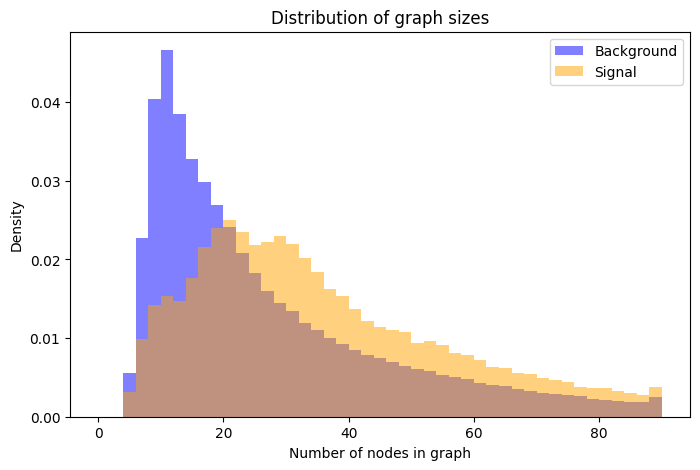

In [2]:
graph_size = np.array([g.num_nodes for g in train_graphs + val_graphs])
graph_labels = np.array([g.y.item() for g in train_graphs + val_graphs])
x_max = np.percentile(graph_size, 95).astype(int)
x_max = (x_max // 2 + 1) * 2  # Round up to nearest 2
bins = np.linspace(0, x_max, x_max // 2 + 1)
fig, ax = plt.subplots(
    figsize=(8, 5),
)
ax.hist(
    graph_size[graph_labels == 0],
    bins=bins,
    alpha=0.5,
    label="Background",
    color="blue",
    density=True,
)
ax.hist(
    graph_size[graph_labels == 1],
    bins=bins,
    alpha=0.5,
    label="Signal",
    color="orange",
    density=True,
)
ax.set_xlabel("Number of nodes in graph")
ax.set_ylabel("Density")
ax.set_title("Distribution of graph sizes")
ax.legend()
plt.savefig(f"{PLOTS_DIR}/graph_size_distribution.png")

In [3]:
from src.torch.model.graph_classifier import SimpleGraphClassifier
from importlib import reload
from src.torch.training import get_class_weights
model = SimpleGraphClassifier(
    node_input_dim=train_graphs[0].x.shape[1],
    hidden_dim=32,
    num_conv_layers=5,
    dropout=0.2,
)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)
bce_loss = torch.nn.BCELoss(weight=get_class_weights(train_graphs).float())

In [4]:
from src.torch.training import train_graph_classifier
train_loader = DataLoader(train_graphs, batch_size=512, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=512, shuffle=False)

model, aucs = train_graph_classifier(
    train_loader, val_loader,model, num_epochs=30, optimizer=optimizer, scheduler=scheduler, criterion=bce_loss
)

Model initialized with 9537 trainable parameters.


Epoch 1/30: 100%|██████████| 1533/1533 [03:31<00:00,  7.23it/s]


Epoch 1/30 - Training loss: 23.3816, AUC: 0.6701
Epoch 1/30 - Validation loss: 21.2366, AUC: 0.7654


Epoch 2/30: 100%|██████████| 1533/1533 [03:54<00:00,  6.54it/s]


Epoch 2/30 - Training loss: 21.1502, AUC: 0.7562
Epoch 2/30 - Validation loss: 20.1504, AUC: 0.7927


...

Epoch 28/30 - Training loss: 16.4587, AUC: 0.8788
Epoch 28/30 - Validation loss: 16.7256, AUC: 0.8883


Epoch 29/30: 100%|██████████| 1533/1533 [04:24<00:00,  5.79it/s]


Epoch 29/30 - Training loss: 16.4014, AUC: 0.8797
Epoch 29/30 - Validation loss: 16.1233, AUC: 0.8923


Epoch 30/30: 100%|██████████| 1533/1533 [05:04<00:00,  5.04it/s]


Epoch 30/30 - Training loss: 16.3545, AUC: 0.8807
Epoch 30/30 - Validation loss: 15.9850, AUC: 0.8917
Best validation AUC: 0.8923


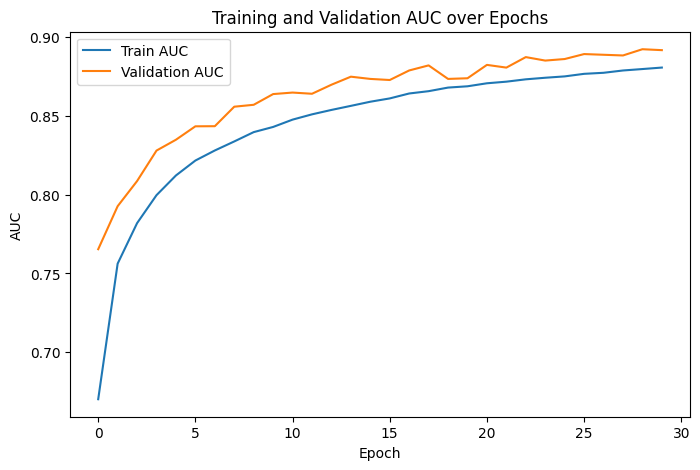

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(aucs["train_aucs"], label="Train AUC")
ax.plot(aucs["val_aucs"], label="Validation AUC")
ax.set_xlabel("Epoch")
ax.set_ylabel("AUC")
ax.set_title("Training and Validation AUC over Epochs")
ax.legend()
plt.savefig(f"{PLOTS_DIR}/graph_classifier_aucs.png")

Evaluating on validation set: 100%|██████████| 384/384 [00:25<00:00, 15.01it/s]


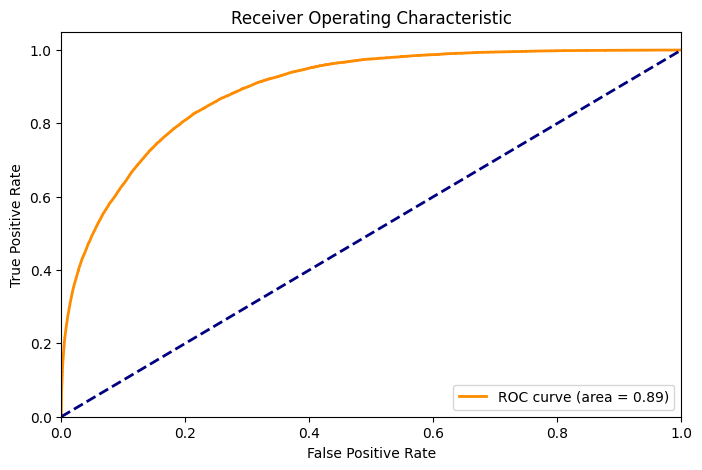

In [7]:
from sklearn.metrics import roc_curve, auc
fig, ax = plt.subplots(figsize=(8, 5))
val_labels = []
val_preds = []
model.eval()
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Evaluating on validation set"):
        out = model(batch)
        val_labels.append(batch.y.cpu())
        val_preds.append(out.cpu())
val_labels = torch.cat(val_labels).numpy()
val_preds = torch.cat(val_preds).numpy()
fpr, tpr, thresholds = roc_curve(val_labels, val_preds)
roc_auc = auc(fpr, tpr)
ax.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
ax.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Receiver Operating Characteristic")
ax.legend(loc="lower right")
plt.savefig(f"{PLOTS_DIR}/graph_classifier_roc_curve.png")